In [ ]:
from statsmodels.tsa.arima.model import ARIMA
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from prophet import Prophet

In [ ]:
df = pd.read_csv("/content/cafe_daily_visitors_2y.csv", parse_dates=["ds"])

print(df.head())
print(df.tail())

          ds    y
0 2023-01-01  154
1 2023-01-02   99
2 2023-01-03  106
3 2023-01-04  113
4 2023-01-05   99
            ds    y
725 2024-12-26  197
726 2024-12-27  199
727 2024-12-28  252
728 2024-12-29  245
729 2024-12-30  194


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 52852 (\N{HANGUL SYLLABLE KA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54168 (\N{HANGUL SYLLABLE PE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51068 (\N{HANGUL SYLLABLE IL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48169 (\N{HANGUL SYLLABLE BANG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 47928 (\N{HANGUL SYLLABLE MUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/lo

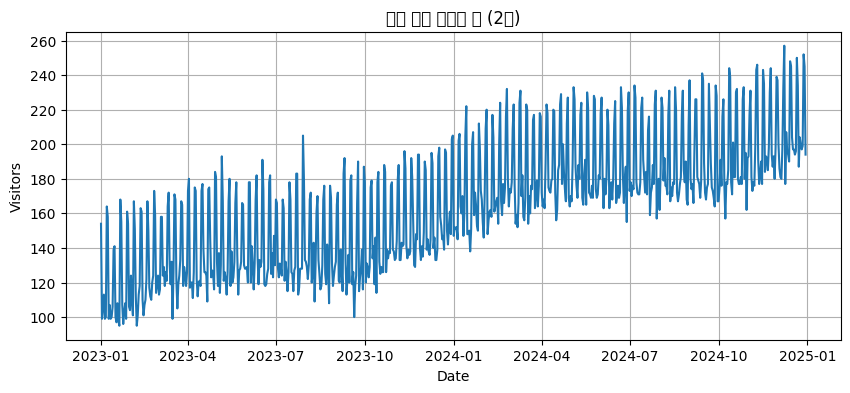

In [ ]:
plt.figure(figsize=(10,4))
plt.plot(df["ds"], df["y"])
plt.title("카페 일일 방문자 수 (2년)")
plt.xlabel("Date")
plt.ylabel("Visitors")
plt.grid(True)
plt.show()

In [ ]:
# 전체적으로 시간이 지날수록 방문자 수가 늘어나는 것처럼 보이나?

# 주말이 더 높은 것 같은 패턴이 보이나? (위아래 톱니 패턴)

# 겨울/여름쯤에 방문자가 상대적으로 많거나 적어 보이는 구간이 있나?

In [ ]:
# 1) Prophet 형식: ds(날짜), y(값) – 이미 이 형식으로 되어 있음
# df = pd.read_csv("cafe_daily_visitors_2y.csv", parse_dates=["ds"])

# 2) 모델 생성 & 학습
m = Prophet(daily_seasonality=True, yearly_seasonality=True)
m.fit(df)


In [ ]:
# 3) 미래 30일 데이터프레임 만들기
future = m.make_future_dataframe(periods=30, freq="D")

In [ ]:
# 4) 예측
forecast = m.predict(future)

In [ ]:
forecast.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,daily,...,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2023-01-01,145.881290,142.066615,161.510522,145.881290,145.881290,6.084985,6.084985,6.084985,-32.050989,...,36.066415,36.066415,36.066415,2.069559,2.069559,2.069559,0.0,0.0,0.0,151.966275
1,2023-01-02,146.023034,92.858765,112.576566,146.023034,146.023034,-43.547981,-43.547981,-43.547981,-32.050989,...,-13.709220,-13.709220,-13.709220,2.212228,2.212228,2.212228,0.0,0.0,0.0,102.475053
2,2023-01-03,146.164778,90.898346,111.009418,146.164778,146.164778,-45.140589,-45.140589,-45.140589,-32.050989,...,-15.407647,-15.407647,-15.407647,2.318047,2.318047,2.318047,0.0,0.0,0.0,101.024189
3,2023-01-04,146.306521,93.306785,112.664439,146.306521,146.306521,-43.753503,-43.753503,-43.753503,-32.050989,...,-14.091309,-14.091309,-14.091309,2.388795,2.388795,2.388795,0.0,0.0,0.0,102.553019
4,2023-01-05,146.448265,91.461603,111.754315,146.448265,146.448265,-44.706847,-44.706847,-44.706847,-32.050989,...,-15.082787,-15.082787,-15.082787,2.426930,2.426930,2.426930,0.0,0.0,0.0,101.741418


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 52852 (\N{HANGUL SYLLABLE KA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54168 (\N{HANGUL SYLLABLE PE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48169 (\N{HANGUL SYLLABLE BANG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 47928 (\N{HANGUL SYLLABLE MUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51088 (\N{HANGUL SYLLABLE JA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/lo

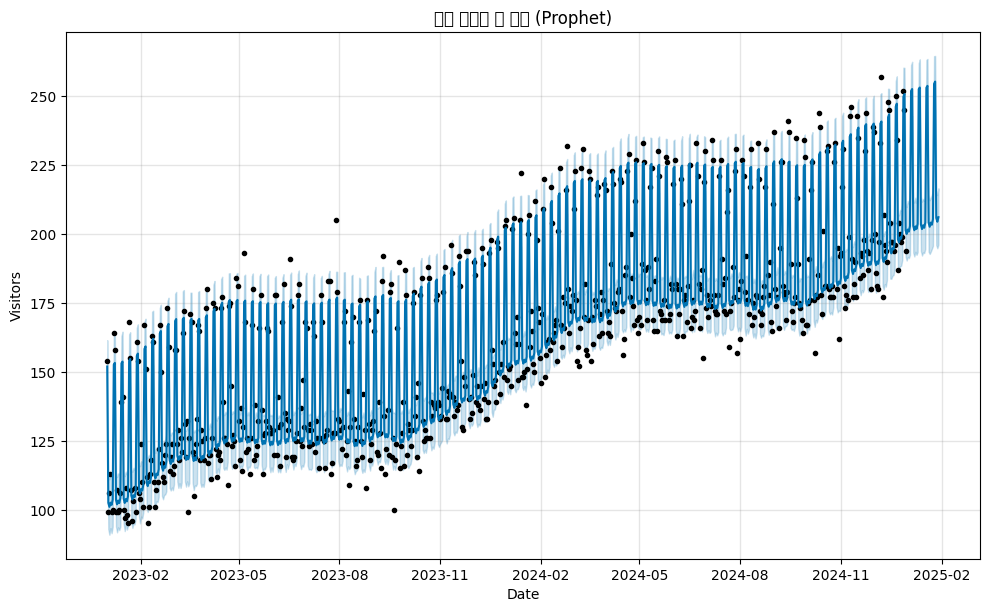

In [ ]:

# 5) 전체 예측 플롯
fig1 = m.plot(forecast)
plt.title("카페 방문자 수 예측 (Prophet)")
plt.xlabel("Date")
plt.ylabel("Visitors")
plt.grid(True)
plt.show()

In [ ]:
# 6) 미래 0일만 따로 보기
forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]].tail(10)

,ds,yhat,yhat_lower,yhat_upper
750,2025-01-20,204.161612,193.605567,214.437622
751,2025-01-21,202.642117,192.775530,212.293433
752,2025-01-22,204.159584,193.598928,213.095026
753,2025-01-23,203.391200,194.599740,214.262067
754,2025-01-24,205.422849,195.707437,215.725617
755,2025-01-25,254.503262,244.554173,264.562026
756,2025-01-26,255.333350,244.950946,264.625851
757,2025-01-27,205.859009,195.991584,215.846468
758,2025-01-28,204.477703,194.836741,214.138033
759,2025-01-29,206.125211,196.199475,216.603074


In [ ]:
# 예측 그래프에서 **전체 추세(점점 증가)**가 잘 반영되어 있는가?

# 예측 곡선에도 주말에 살짝 튀는 패턴이 남아 있는가?

# yhat_lower, yhat_upper 범위는 대략 어느 정도 폭인지? (불확실성 크기 느낌)

In [ ]:
from statsmodels.tsa.arima.model import ARIMA
import numpy as np

series = df.set_index("ds")["y"]


In [ ]:
# (1) 마지막 60일을 테스트로 남겨두고, 나머지로 학습
train = series.iloc[:-60]
test = series.iloc[-60:]

In [ ]:
# (2) ARIMA(1,1,1) 모델 학습
model = ARIMA(train, order=(1,1,1))
fit = model.fit()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


In [ ]:
# (3) 향후 60일 예측
forecast_res = fit.get_forecast(steps=60)
pred_mean = forecast_res.predicted_mean
conf_int = forecast_res.conf_int()

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 52852 (\N{HANGUL SYLLABLE KA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54168 (\N{HANGUL SYLLABLE PE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48169 (\N{HANGUL SYLLABLE BANG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 47928 (\N{HANGUL SYLLABLE MUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51088 (\N{HANGUL SYLLABLE JA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/lo

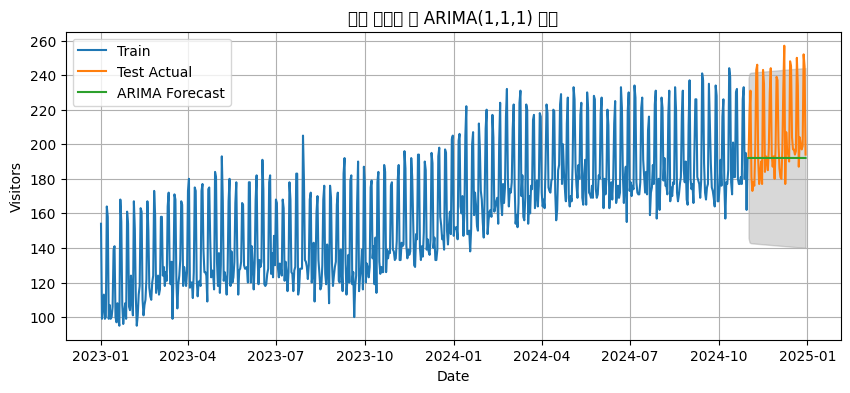

In [ ]:
# (4) 실제 vs 예측 그래프
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.plot(train.index, train, label="Train")
plt.plot(test.index, test, label="Test Actual")
plt.plot(pred_mean.index, pred_mean, label="ARIMA Forecast")
plt.fill_between(pred_mean.index,
                 conf_int.iloc[:,0],
                 conf_int.iloc[:,1],
                 color="gray", alpha=0.3)
plt.title("카페 방문자 수 ARIMA(1,1,1) 예측")
plt.xlabel("Date")
plt.ylabel("Visitors")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
# ARIMA 예측선이 테스트 실제값을 대체로 잘 따라가나?

# Prophet 예측과 비교해서, 둘 중 무엇이 더 부드럽고 자연스러운지 느껴보기.

# “카페 방문자 수”처럼 주기+추세가 섞인 데이터에서는
# → Prophet / ARIMA 중 어느 쪽이 더 쓰기 편해 보이는지?

In [ ]:
# 평일 평균 방문자

# 주말 평균 방문자

# 둘 중 어느 쪽이 더 많은지

In [ ]:
import pandas as pd

df = pd.read_csv("cafe_daily_visitors_2y.csv", parse_dates=["ds"])

# 요일 정보 추가 (월=0, …, 일=6)
df["weekday"] = df["ds"].dt.weekday

# 평일 / 주말 구분
df["is_weekend"] = df["weekday"].apply(lambda x: 1 if x >= 5 else 0)

In [ ]:
# 평균 계산
weekday_mean = df[df["is_weekend"] == 0]["y"].mean()
weekend_mean = df[df["is_weekend"] == 1]["y"].mean()

In [ ]:
print("평일 평균 방문자:", round(weekday_mean, 2))
print("주말 평균 방문자:", round(weekend_mean, 2))

평일 평균 방문자: 149.81
주말 평균 방문자: 200.06


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54217 (\N{HANGUL SYLLABLE PYEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51068 (\N{HANGUL SYLLABLE IL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51452 (\N{HANGUL SYLLABLE JU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 47568 (\N{HANGUL SYLLABLE MAL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44512 (\N{HANGUL SYLLABLE GYUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/us

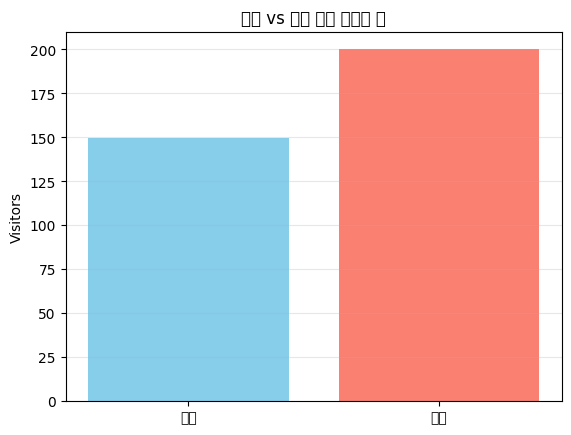

In [ ]:
import matplotlib.pyplot as plt

plt.bar(["평일", "주말"], [weekday_mean, weekend_mean], color=["skyblue", "salmon"])
plt.title("평일 vs 주말 평균 방문자 수")
plt.ylabel("Visitors")
plt.grid(axis="y", alpha=0.3)
plt.show()

In [ ]:
# 주말과 평일 중 어느 쪽이 평균 방문자가 더 많은가?

# 그 차이가 크다 / 보통이다 / 작다 중 어느 정도라고 느껴지는가?

# 이 패턴은 ARIMA / Prophet 예측에도 어떤 영향을 줄 것으로 예상되는가?

# 힌트: 주말 효과는 주기성(seasonality)

In [ ]:
# 주말/평일을 통합해 “요일별 평균”을 구해보시오. (월~일 7개)


df["weekday_name"] = df["ds"].dt.day_name()

weekday_avg = df.groupby("weekday_name")["y"].mean()
print(weekday_avg)


weekday_name
Friday       151.000000
Monday       150.533333
Saturday     199.951923
Sunday       200.171429
Thursday     149.076923
Tuesday      148.480769
Wednesday    149.932692
Name: y, dtype: float64


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50836 (\N{HANGUL SYLLABLE YO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51068 (\N{HANGUL SYLLABLE IL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54217 (\N{HANGUL SYLLABLE PYEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44512 (\N{HANGUL SYLLABLE GYUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/

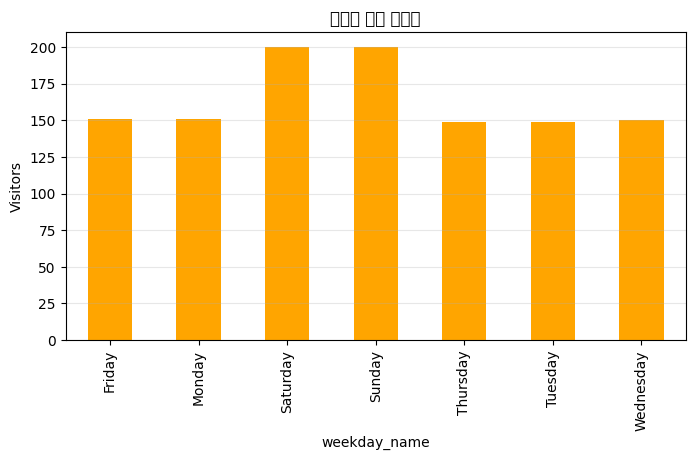

In [ ]:
weekday_avg.plot(kind="bar", figsize=(8,4), color="orange")
plt.title("요일별 평균 방문자")
plt.ylabel("Visitors")
plt.grid(axis="y", alpha=0.3)
plt.show()


In [ ]:
# 가장 방문자가 많은 요일은?

# 가장 적은 요일은?

# 주말 효과 외에 요일별로 특이한 패턴이 있는가?

In [ ]:
# Prophet에 “주말 효과” 반영하는 버전

# 요일별 dummy variable로 ARIMAX 모델 만들기

# “주말·평일 변화가 1년 동안 어떻게 변했는지” 추가 시각화

In [ ]:
import pandas as pd

df = pd.read_csv("cafe_daily_visitors_2y.csv", parse_dates=["ds"])

# 요일 생성 (월=0 ~ 일=6)
df["weekday"] = df["ds"].dt.weekday

# 주말 여부(토·일)
df["is_weekend"] = df["weekday"].apply(lambda x: 1 if x >= 5 else 0)

# 평균 계산
weekday_mean = df[df["is_weekend"] == 0]["y"].mean()
weekend_mean = df[df["is_weekend"] == 1]["y"].mean()

print("평일 평균 방문자:", round(weekday_mean, 1))
print("주말 평균 방문자:", round(weekend_mean, 1))


평일 평균 방문자: 149.8
주말 평균 방문자: 200.1


In [ ]:
# 주말과 평일의 차이는 몇 명 정도인가?

# 체감적으로 “주말 효과가 크다 / 보통이다 / 작다” 중 어디에 가깝다고 생각하는가?

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54217 (\N{HANGUL SYLLABLE PYEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51068 (\N{HANGUL SYLLABLE IL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51452 (\N{HANGUL SYLLABLE JU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 47568 (\N{HANGUL SYLLABLE MAL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44512 (\N{HANGUL SYLLABLE GYUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/us

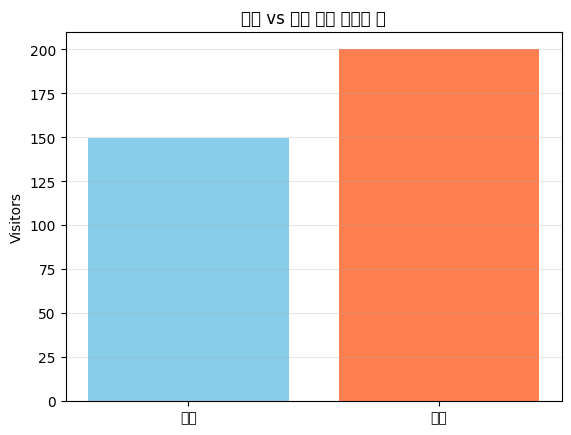

In [ ]:
# 평일·주말 평균을 막대그래프로 비교

import matplotlib.pyplot as plt

plt.bar(["평일", "주말"], [weekday_mean, weekend_mean],
        color=["skyblue", "coral"])

plt.title("평일 vs 주말 평균 방문자 수")
plt.ylabel("Visitors")
plt.grid(axis="y", alpha=0.3)
plt.show()


In [ ]:
# 그래프에서 두 막대의 차이가 시각적으로도 잘 드러나는가?

# 만약 실제 매출이 방문자 수에 비례한다면,
# 주말 대비 평일 운영 전략은 어떻게 달라질 수 있을까?

In [ ]:
# 주말/평일을 넘어, 요일별(월~일) 평균도 비교
df["weekday_name"] = df["ds"].dt.day_name()

weekday_avg = df.groupby("weekday_name")["y"].mean().sort_values()
print(weekday_avg)


weekday_name
Tuesday      148.480769
Thursday     149.076923
Wednesday    149.932692
Monday       150.533333
Friday       151.000000
Saturday     199.951923
Sunday       200.171429
Name: y, dtype: float64


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50836 (\N{HANGUL SYLLABLE YO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51068 (\N{HANGUL SYLLABLE IL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54217 (\N{HANGUL SYLLABLE PYEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44512 (\N{HANGUL SYLLABLE GYUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/

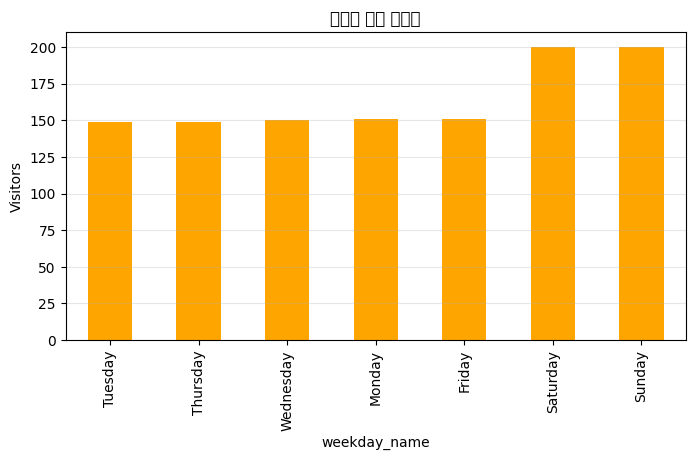

In [ ]:
weekday_avg.plot(kind="bar", figsize=(8,4), color="orange")
plt.title("요일별 평균 방문자")
plt.ylabel("Visitors")
plt.grid(axis="y", alpha=0.3)
plt.show()


In [ ]:
# 가장 방문자가 많은 요일은?

# 가장 적은 요일은?

# “금요일 → 토요일 → 일요일”로 이어지는 패턴에 어떤 변화가 있는가?